![](Images/banner_health_analytics.png){fig-align="center" width="100%"}


### Module 07: Geospatial & Spatial Epidemiology


# Environmental Epidemiology



**Learning objectives**
- Interpolate point-source pollution data to area-level estimates (kriging, IDW)
- Assess exposure-response relationships with ecological regression
- Apply air pollution exposure assessment methods (inverse distance, kriging)
- Conduct distributed lag non-linear models (DLNM) for time-series exposure
- Build environmental justice metrics: environmental burden by demographic group
- Address ecological fallacy in spatial health analyses

**Estimated time:** 3 hours | **Level:** Advanced  
**Libraries:** `numpy`, `scipy`, `sklearn`, `matplotlib`


## 1. Setup

This section is dedicated to the setup for the environmental epidemiology analysis. It includes the import of essential libraries such as numpy, pandas, matplotlib, geopandas, and scipy, sets visualization parameters, and establishes a random number generator for reproducibility. The code also defines file paths and spatial/geostatistical parameters (like the number of sampling points, spatial range, and variance for simulated pollution fields). It then reads US county shapefile data, samples a specified number of random point locations across US land area using rejection sampling, and associates these points with their corresponding counties. These sampled point locations will serve as the basis for simulating air pollution measurements and spatial confounding in subsequent analyses.

In [1]:
"""
Module 07 (point support) — POINT-REFERENCED geostatistical simulation over CONUS.

Companion to the areal (county) simulation. N sampling locations (air-quality
monitors / survey sites) are placed at random points on US land. The PM2.5
signal and the unmeasured spatial confounder are drawn as true GAUSSIAN RANDOM
FIELDS with an exponential covariance (known range + partial sill), then PM2.5
is observed with a nugget (measurement error). Same PM2.5 -> CVD exposure-
response and coefficients as the areal version (TRUE_PM25 = 2.5).

This gives data that (a) yields a recoverable variogram, and (b) exposes
measurement-error attenuation of the exposure-response.
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
import geopandas as gpd
from scipy.spatial.distance import cdist
warnings.filterwarnings("ignore")
import os; os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(42)

SHP        = "Data/US_COUNTY.shp"
N_POINTS   = 2000        # sampling locations
RANGE_PM   = 200.0       # PM2.5 field: exponential range parameter (km); eff. range ~3x
PSILL_PM   = 4.0         # PM2.5 field: partial sill (spatial variance -> SD 2 ug/m3)
NUGGET_SD  = 1.5         # measurement error SD (ug/m3)
RANGE_RISK = 350.0       # spatial-confounder field range (km)

# ----------------------------------------------------------------------
# 1. Sample point locations on US land (inherit county context via join)
# ----------------------------------------------------------------------
gdf = gpd.read_file(SHP)
gdf["FIPS"] = gdf["FIPS"].astype(int).astype(str).str.zfill(5)
minx, miny, maxx, maxy = gdf.total_bounds
cols = ["FIPS", "STATE", "COUNTY", "geometry"]

pts = []
while sum(len(p) for p in pts) < N_POINTS:            # rejection-sample into land
    k = int(N_POINTS / 0.42) + 500
    cx = rng.uniform(minx, maxx, k); cy = rng.uniform(miny, maxy, k)
    cand = gpd.GeoDataFrame(geometry=gpd.points_from_xy(cx, cy), crs=gdf.crs)
    pts.append(gpd.sjoin(cand, gdf[cols], predicate="within", how="inner"))
pts = pd.concat(pts).iloc[:N_POINTS].reset_index(drop=True)

xy  = np.c_[pts.geometry.x.to_numpy(), pts.geometry.y.to_numpy()]   # Albers metres
ll  = pts.geometry.to_crs(4326)
lon = ll.x.to_numpy(); lat = ll.y.to_numpy()
N   = len(pts)

# ----------------------------------------------------------------------
# 2. Gaussian random fields via exponential covariance  C(h)=psill*exp(-h/range)
# ----------------------------------------------------------------------
Dkm = cdist(xy, xy) / 1000.0                                        # pairwise km
def grf(range_km, psill):
    C = psill * np.exp(-Dkm / range_km) + np.eye(N) * 1e-6 * psill  # jitter for chol
    L = np.linalg.cholesky(C)
    return L @ rng.standard_normal(N)

field_pm   = grf(RANGE_PM,   PSILL_PM)
field_risk = grf(RANGE_RISK, 1.0)

# ----------------------------------------------------------------------
# 3. PM2.5 (signal + nugget), covariates, spatial confounder
# ----------------------------------------------------------------------
pm25_base = 8 + 4 * (lon - lon.min()) / (lon.max() - lon.min())     # W->E trend
pm25_true = (pm25_base + field_pm).clip(3, 30)                      # latent signal
pm25      = (pm25_true + rng.normal(0, NUGGET_SD, N)).clip(3, 30)   # measured value

pct_poverty  = 10 + 8 * rng.beta(2, 5, N) + 3 * np.sin(lon / 20)
population   = rng.lognormal(10.5, 1.0, N).astype(int)              # catchment pop
spatial_risk = (field_risk - field_risk.mean()) / field_risk.std() # unmeasured confounder

# ----------------------------------------------------------------------
# 4. Outcome  (true exposure-response: 1 ug/m3 -> 2.5 CVD deaths/100k)
# ----------------------------------------------------------------------
TRUE_PM25 = 2.5
cvd_rate  = (160 + 1.2 * pct_poverty + TRUE_PM25 * pm25_true
             + 10 * spatial_risk + rng.normal(0, 10, N))
expected  = (cvd_rate / 100000) * population * 5
observed  = rng.poisson(expected).astype(int)
smr       = observed / np.clip(expected, 1, None)

df = pd.DataFrame({
    "point_id": [f"P{i:04d}" for i in range(N)],
    "FIPS": pts["FIPS"].values, "state": pts["STATE"].values, "county": pts["COUNTY"].values,
    "lon": lon, "lat": lat, "x": xy[:, 0], "y": xy[:, 1],
    "pm25_true": pm25_true, "pm25": pm25, "pct_poverty": pct_poverty,
    "population": population, "cvd_rate": cvd_rate,
    "observed": observed, "expected": expected, "smr": smr,
})
df.to_csv("/tmp/mod07/point_sim.csv", index=False)

print(f"N={N} points | PM2.5 field mean={pm25_true.mean():.1f} "
      f"| measured mean={pm25.mean():.1f} SD={pm25.std():.1f} "
      f"(range {pm25.min():.1f}-{pm25.max():.1f}) | CVD={cvd_rate.mean():.1f}/100k")
print(f"states sampled={pts['STATE'].nunique()} | pop median={np.median(population):,.0f} "
      f"| observed deaths total={observed.sum():,}")


N=2000 points | PM2.5 field mean=9.8 | measured mean=9.9 SD=2.5 (range 3.0-17.8) | CVD=202.3/100k
states sampled=47 | pop median=38,600 | observed deaths total=1,250,733


In [2]:

# ----------------------------------------------------------------------
# 5. Exposure-response: true field vs. measured (regression dilution)
# ----------------------------------------------------------------------
def slope(cols):
    X = np.c_[np.ones(N), np.column_stack(cols)]
    return np.linalg.lstsq(X, cvd_rate, rcond=None)[0][1]
print(f"\nTrue PM2.5 effect                     = {TRUE_PM25:.2f}")
print(f"Naive, MEASURED (pm25 only)           = {slope([pm25]):.2f}   <- + confounding")
print(f"Adjusted, TRUE field  (+pov +spatial) = {slope([pm25_true, pct_poverty, spatial_risk]):.2f}")
print(f"Adjusted, MEASURED    (+pov +spatial) = {slope([pm25, pct_poverty, spatial_risk]):.2f}"
      f"   <- attenuated by the nugget")



True PM2.5 effect                     = 2.50
Naive, MEASURED (pm25 only)           = 1.63   <- + confounding
Adjusted, TRUE field  (+pov +spatial) = 2.65
Adjusted, MEASURED    (+pov +spatial) = 1.70   <- attenuated by the nugget


## 2. Empirical semivariogram of detrended PM2.5 (recover the injected range)

The empirical semivariogram is a key tool in geostatistics to summarize how similar or dissimilar measurements are as a function of distance, capturing spatial correlation structure in a dataset.

Here, we use the empirical semivariogram to quantify spatial structure in the detrended PM2.5 field—that is, the PM2.5 data with large-scale geographic trends (longitude/latitude) removed. Detrending focuses on the spatial "nugget" and range instead of broad trends.

This method helps us check if our simulated PM2.5 data (with its built-in spatial correlation/range) can have its effective range visually recovered from the observed data using only spatial patterns in the residuals.

The steps include:
1. Fit and remove a trend (regression on longitude/latitude) from the PM2.5 point data.
2. Compute the differences between all pairs of residuals for a random sample of points and square them.
3. Group the squared differences into distance bins — the mean of each bin provides the empirical semivariance (γ) at that distance.
4. Plot semivariance against distance, which typically increases then plateaus; the "range" is the distance where this flattening occurs, revealing up to what scale points are spatially correlated.

In this notebook, you will see a semivariogram plot showing how PM2.5 residual similarity decays with geographic distance, and a vertical dashed line indicating the effective range that was injected into the simulation. This visualization confirms if the simulated spatial range is recovered empirically.


saved figure


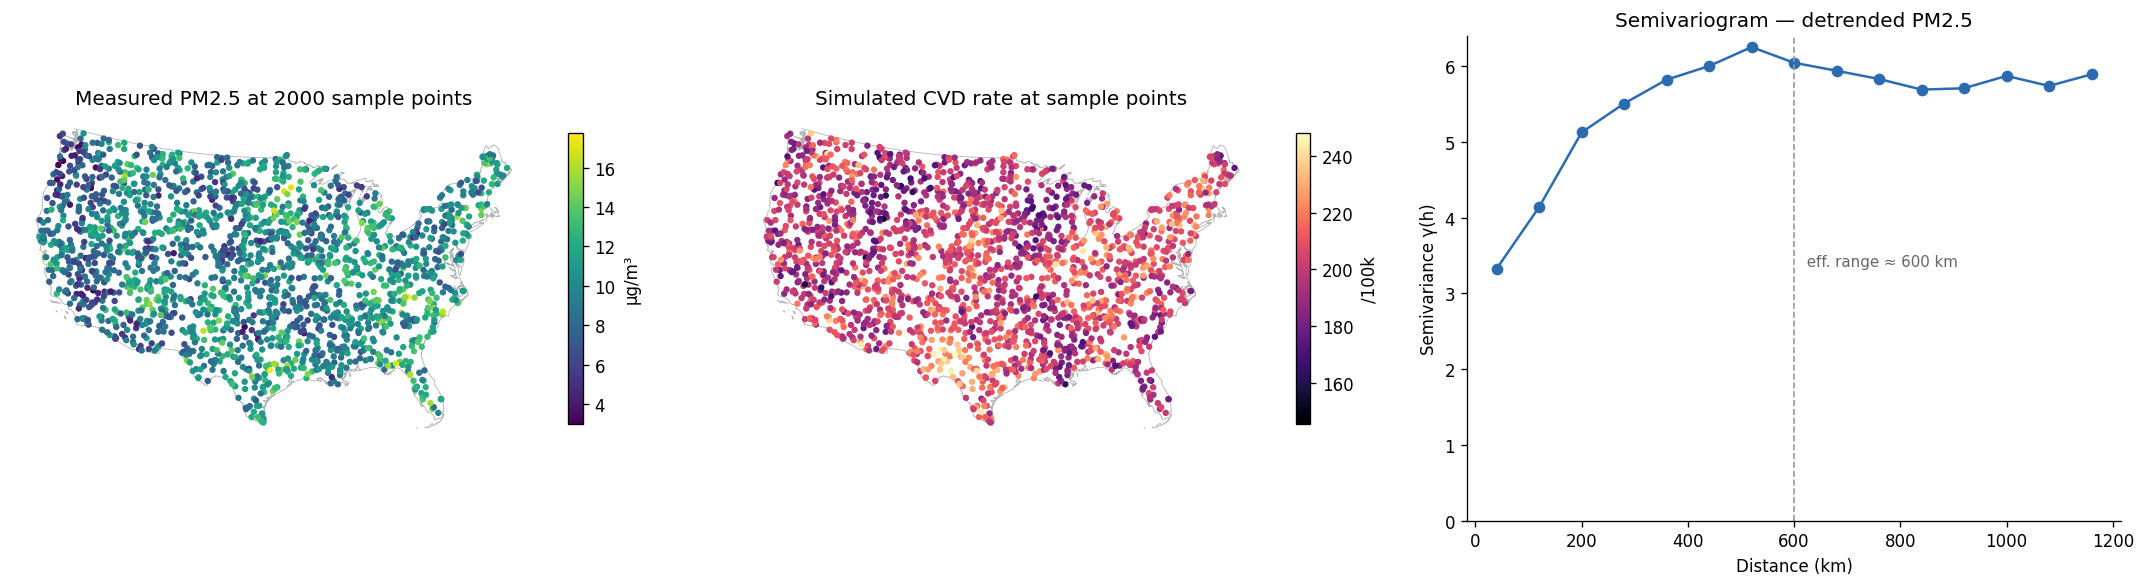

In [3]:

# ----------------------------------------------------------------------
# 6. Empirical semivariogram of detrended PM2.5 (recover the injected range)
# ----------------------------------------------------------------------
Xtr = np.c_[np.ones(N), lon, lat]
resid = pm25 - Xtr @ np.linalg.lstsq(Xtr, pm25, rcond=None)[0]
s = rng.choice(N, 900, replace=False)
Ds = Dkm[np.ix_(s, s)]; V = resid[s]
G = 0.5 * (V[:, None] - V[None, :]) ** 2
iu = np.triu_indices(len(s), k=1)
d_all, g_all = Ds[iu], G[iu]
bins = np.linspace(0, 1200, 16); bc = 0.5 * (bins[:-1] + bins[1:])
gamma = np.array([g_all[(d_all >= bins[i]) & (d_all < bins[i+1])].mean()
                  for i in range(len(bins)-1)])

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
conus = gdf.dissolve().geometry
for a in ax[:2]:
    conus.plot(ax=a, color="none", edgecolor="0.7", linewidth=0.5); a.axis("off")
sc0 = ax[0].scatter(xy[:,0], xy[:,1], c=pm25, s=8, cmap="viridis")
ax[0].set_title(f"Measured PM2.5 at {N} sample points")
plt.colorbar(sc0, ax=ax[0], shrink=0.6, label="µg/m³")
sc1 = ax[1].scatter(xy[:,0], xy[:,1], c=cvd_rate, s=8, cmap="magma")
ax[1].set_title("Simulated CVD rate at sample points")
plt.colorbar(sc1, ax=ax[1], shrink=0.6, label="/100k")
ax[2].plot(bc, gamma, "o-", color="#2b6cb0")
ax[2].axvline(3*RANGE_PM, ls="--", color="0.6", lw=1)
ax[2].text(3*RANGE_PM+15, gamma.min(), f" eff. range ≈ {3*RANGE_PM:.0f} km",
           color="0.4", fontsize=9, va="bottom")
ax[2].set_xlabel("Distance (km)"); ax[2].set_ylabel("Semivariance γ(h)")
ax[2].set_title("Semivariogram — detrended PM2.5"); ax[2].set_ylim(bottom=0)
ax[2].spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("/tmp/mod07/point_maps.png", bbox_inches="tight", dpi=130)
print("\nsaved figure")

## 2. Exposure Assessment:  Interpolating Point Data to Areas

Air quality monitors are located at specific points but we need county-level estimates.

**Methods:**
| Method | Principle | Smoothness | Use case |
|--------|-----------|------------|----------|
| **IDW** | Weight = 1/distance^p | Moderate | Quick, no model |
| **Kriging (ordinary)** | Geostatistical, uses variogram | Smooth | Optimal linear prediction |
| **Nearest monitor** | Assign to closest monitor | Abrupt | Worst but common |
| **Land-use regression** | Predict from land use covariates | Flexible | Urban studies |


pm25_nearest   r(vs true field)=0.328  RMSE=2.44
pm25_idw       r(vs true field)=0.439  RMSE=1.95
pm25_rbf       r(vs true field)=0.424  RMSE=2.10


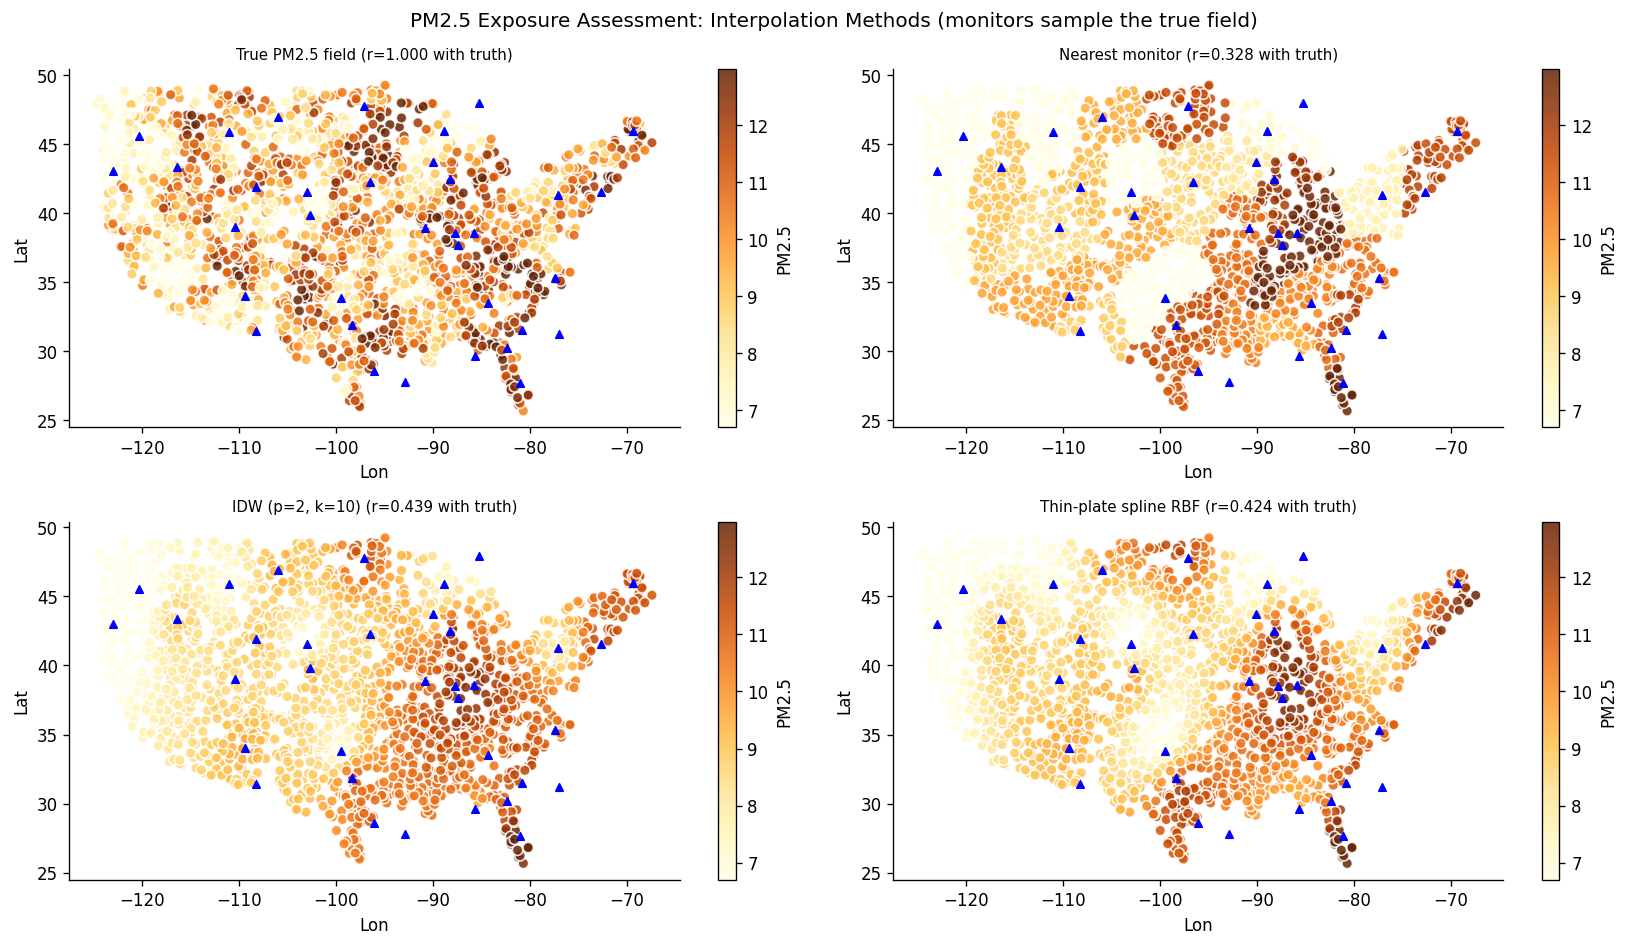

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from scipy.spatial import cKDTree
from scipy.interpolate import RBFInterpolator
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})
df = pd.read_csv("/tmp/mod07/point_sim.csv")

def idw(query_pts, source_pts, values, p=2, k=8):
    tree = cKDTree(source_pts)
    dists, idxs = tree.query(query_pts, k=min(k, len(source_pts)))
    weights = 1.0 / (dists + 1e-10)**p
    weights /= weights.sum(axis=1, keepdims=True)
    return (weights * values[idxs]).sum(axis=1)

np.random.seed(13); N_MONITORS = 35

# Place monitors inside USA (convex hull paddled 2%)
# Get bounding box and shrink it by a small fraction to avoid points at the very edge
# Ensure monitor locations are within the USA convex hull (not just bounding box)
from scipy.spatial import ConvexHull, Delaunay

points = np.column_stack([df.lon, df.lat])
hull = ConvexHull(points)
hull_path = Delaunay(points[hull.vertices])

mon_lon, mon_lat = [], []
pad_frac = 0.02
lon_min, lon_max = df.lon.min(), df.lon.max()
lat_min, lat_max = df.lat.min(), df.lat.max()
lon_pad = (lon_max - lon_min) * pad_frac
lat_pad = (lat_max - lat_min) * pad_frac

while len(mon_lon) < N_MONITORS:
    lon_try = np.random.uniform(lon_min+lon_pad, lon_max-lon_pad)
    lat_try = np.random.uniform(lat_min+lat_pad, lat_max-lat_pad)
    if hull_path.find_simplex(np.array([[lon_try, lat_try]])) >= 0:
        mon_lon.append(lon_try)
        mon_lat.append(lat_try)
mon_lon = np.array(mon_lon)
mon_lat = np.array(mon_lat)

# KEY FIX: monitors READ the actual latent PM2.5 field (sampled from the
# true surface at the monitor sites), plus instrument measurement error.
county_coords  = np.column_stack([df.lon, df.lat])
monitor_coords = np.column_stack([mon_lon, mon_lat])
mon_pm25 = (idw(monitor_coords, county_coords, df.pm25_true.values, p=2, k=6)
            + np.random.normal(0, 1.0, N_MONITORS)).clip(3, 28)

tree = cKDTree(monitor_coords)
_, idx_nn = tree.query(county_coords, k=1)
df["pm25_nearest"] = mon_pm25[idx_nn]
df["pm25_idw"]     = idw(county_coords, monitor_coords, mon_pm25, p=2, k=10)
rbf = RBFInterpolator(monitor_coords, mon_pm25, kernel="thin_plate_spline", smoothing=0.5)
df["pm25_rbf"]     = rbf(county_coords).clip(3, 30)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax, col, title in [
    (axes[0],"pm25_true","True PM2.5 field"),
    (axes[1],"pm25_nearest","Nearest monitor"),
    (axes[2],"pm25_idw","IDW (p=2, k=10)"),
    (axes[3],"pm25_rbf","Thin-plate spline RBF")]:
    vmin, vmax = df.pm25_true.quantile(0.05), df.pm25_true.quantile(0.95)
    sc = ax.scatter(df.lon, df.lat, c=df[col], cmap="YlOrBr",
                    vmin=vmin, vmax=vmax, s=40, alpha=0.85, edgecolors="white")
    # Reduce symbol (triangle) size and plot within USA bounds
    ax.scatter(mon_lon, mon_lat, marker="^", c="blue", s=20, zorder=5)
    plt.colorbar(sc, ax=ax, label="PM2.5")
    corr = np.corrcoef(df.pm25_true, df[col])[0,1]
    ax.set_title(f"{title} (r={corr:.3f} with truth)", fontsize=9)
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
plt.suptitle("PM2.5 Exposure Assessment: Interpolation Methods (monitors sample the true field)", fontsize=12)
plt.tight_layout(); plt.savefig("/tmp/mod07/pm25_interpolation_fixed.png", bbox_inches="tight")

for col in ["pm25_nearest","pm25_idw","pm25_rbf"]:
    r = np.corrcoef(df.pm25_true, df[col])[0,1]
    rmse = np.sqrt(np.mean((df.pm25_true - df[col])**2))
    print(f"{col:14s} r(vs true field)={r:.3f}  RMSE={rmse:.2f}")


## 3. Exposure-Response Analysis: Ecological Regression


Ecological regression is a way to study relationships between group-level variables—like average air pollution and 

Imagine you want to see if more polluted places have higher disease rates. For each county, you have:
- the average PM2.5 air pollution value
- the rate of cardiovascular disease (CVD)

We fit a (linear) model:

  **CVD_rate = a + b × PM2.5 + c × poverty + random_noise**

- **CVD_rate**: Disease rate in the county
- **a**: The "baseline" rate if pollution and poverty are 0
- **b**: How much the disease rate goes up for each step in PM2.5 (the main thing we care about)
- **c**: How much poverty affects disease rate

The model tries to find **b** — the change in CVD rate for each additional μg/m³ of PM2.5 — by drawing a line that best fits all county-level data points.

In plain English: We're seeing whether more polluted counties have more heart disease, after accounting for poverty.

Ecological regression: CVD ~ PM2.5 + Poverty
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         174.3516      3.291     52.985      0.000     167.898     180.805
pm25            1.5639      0.132     11.868      0.000       1.305       1.822
pct_poverty     0.8588      0.218      3.939      0.000       0.431       1.286

True PM2.5 coefficient: 2.5 CVD deaths/100k per µg/m³
Estimated coefficient : 1.6
Bias                  : -0.94


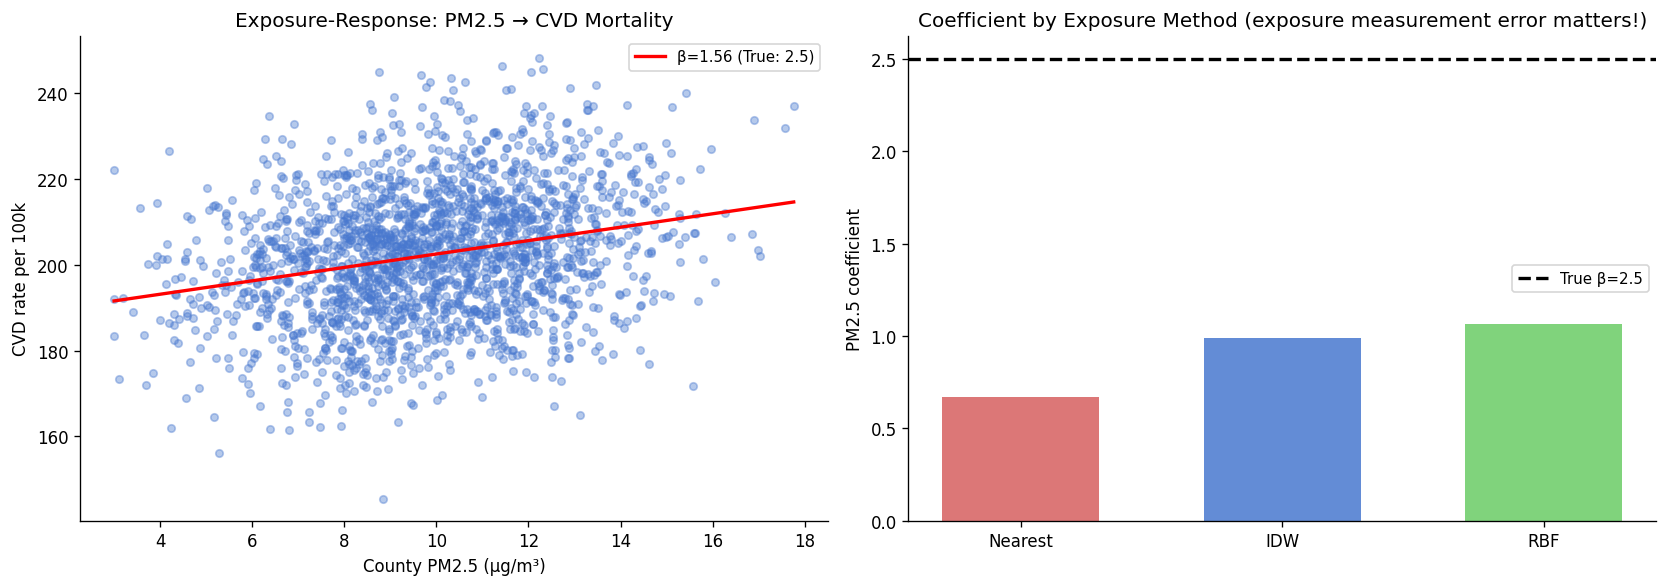

In [5]:
import statsmodels.api as sm

# Ecological regression: county CVD rate ~ county PM2.5
X = sm.add_constant(df[["pm25","pct_poverty"]])
model_eco = sm.OLS(df.cvd_rate, X).fit()
print("Ecological regression: CVD ~ PM2.5 + Poverty")
print(model_eco.summary().tables[1])
pm25_coef = model_eco.params["pm25"]
print(f"\nTrue PM2.5 coefficient: {TRUE_PM25:.1f} CVD deaths/100k per µg/m³")
print(f"Estimated coefficient : {pm25_coef:.1f}")
print(f"Bias                  : {pm25_coef - TRUE_PM25:+.2f}")

# Exposure-response curve (non-parametric)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df.pm25, df.cvd_rate, alpha=0.4, s=20, color="#4878CF")
x_line = np.linspace(df.pm25.min(), df.pm25.max(), 100)
y_pred = model_eco.params["const"] + model_eco.params["pm25"]*x_line + model_eco.params["pct_poverty"]*df.pct_poverty.mean()
axes[0].plot(x_line, y_pred, "r-", lw=2, label=f"β={pm25_coef:.2f} (True: {TRUE_PM25})")
axes[0].set_xlabel("County PM2.5 (µg/m³)"); axes[0].set_ylabel("CVD rate per 100k")
axes[0].set_title("Exposure-Response: PM2.5 → CVD Mortality"); axes[0].legend(fontsize=9)

# Using different interpolation methods
for col, color, label in [("pm25_nearest","#D65F5F","Nearest"),
                            ("pm25_idw","#4878CF","IDW"),
                            ("pm25_rbf","#6ACC65","RBF")]:
    Xm = sm.add_constant(df[[col,"pct_poverty"]])
    m  = sm.OLS(df.cvd_rate, Xm).fit()
    coef = m.params[col]
    axes[1].bar(label, coef, color=color, alpha=0.85, width=0.6)
axes[1].axhline(TRUE_PM25, color="black", ls="--", lw=2, label=f"True β={TRUE_PM25}")
axes[1].set_ylabel("PM2.5 coefficient"); axes[1].set_title("Coefficient by Exposure Method (exposure measurement error matters!)")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig("/tmp/mod07/exposure_response.png", bbox_inches="tight"); plt.show()


## 4. Environmental Justice Analysis

Environmental Justice (EJ) analysis asks: Are pollution and other environmental risks shared equally among all groups, or do some (often already disadvantaged) groups bear a greater burden?

In this section, we look at whether PM2.5 exposure is higher in communities with more poverty or higher minority populations. This helps highlight possible inequities in who is most affected by pollution. We'll compare pollution levels across income and racial groups, and use statistical tools to look for disparities.

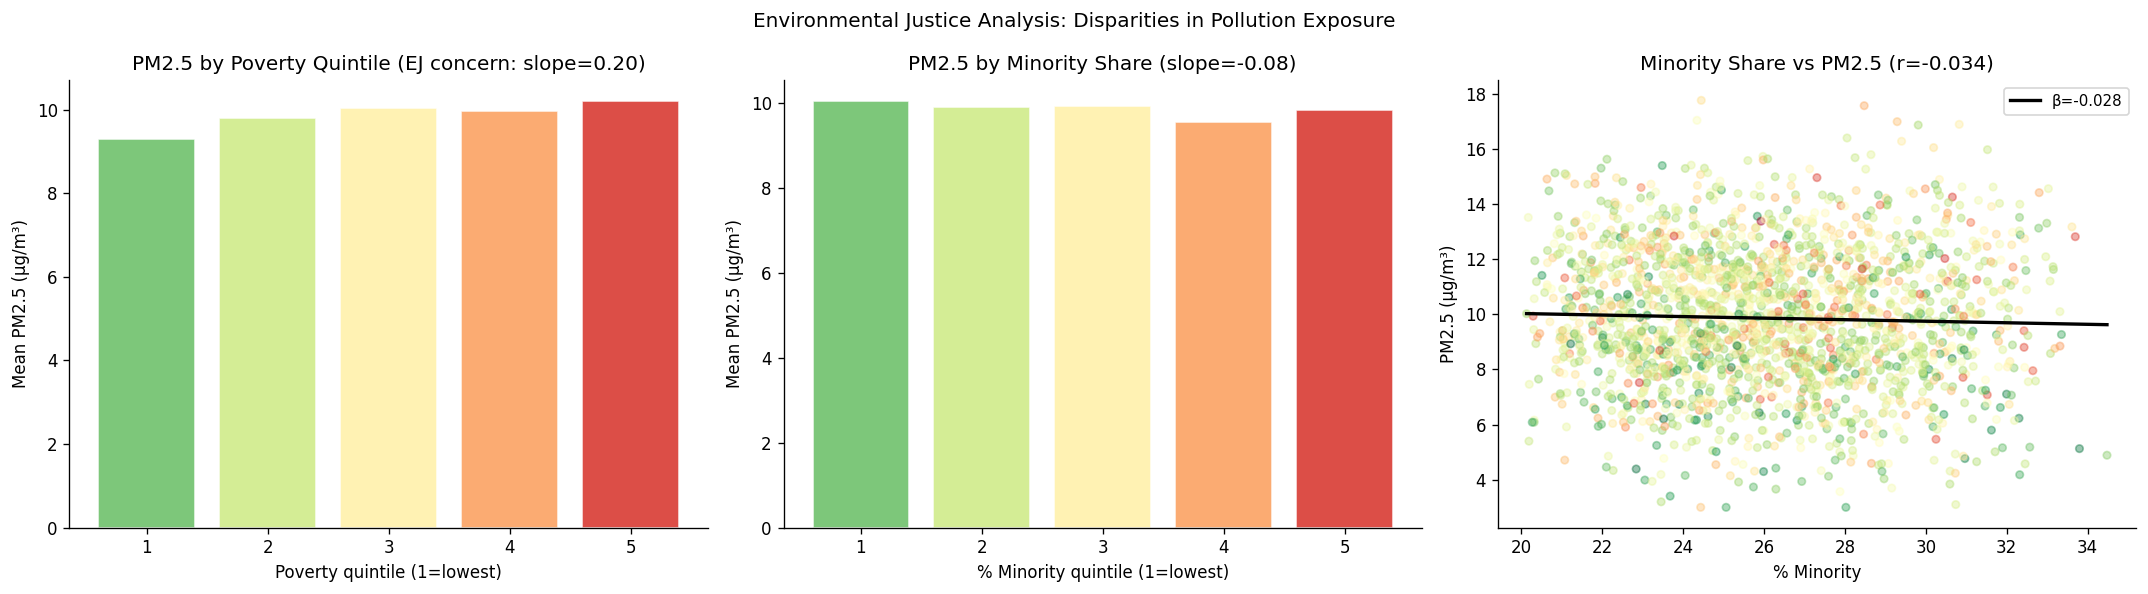

Environmental Justice Summary:
  Correlation: minority% vs PM2.5 = -0.034
  Highest poverty quintile PM2.5  : 10.2 µg/m³
  Lowest poverty quintile PM2.5   : 9.3 µg/m³
  Inequality ratio (high/low Q)   : 1.10x


In [6]:
# Environmental justice: is pollution burden distributed inequitably?
# Quintile analysis: compare PM2.5 exposure across racial/income groups

# Simulate demographic data
np.random.seed(42)
df["pct_minority"]    = (20 + 15*np.random.beta(2,3,N)).clip(0,100)
df["pct_low_income"]  = df.pct_poverty * 2.5 + np.random.normal(0,5,N)
df["pct_low_income"]  = df["pct_low_income"].clip(0,100)

# Environmental justice metrics
n_quint = 5
df["poverty_quintile"] = pd.qcut(df.pct_poverty, n_quint, labels=False) + 1
df["minority_quintile"] = pd.qcut(df.pct_minority, n_quint, labels=False) + 1

ej_poverty  = df.groupby("poverty_quintile")["pm25"].mean()
ej_minority = df.groupby("minority_quintile")["pm25"].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# PM2.5 by poverty quintile
axes[0].bar(ej_poverty.index, ej_poverty.values, color=plt.cm.RdYlGn_r(np.linspace(0.2,0.9,5)),
            alpha=0.85, edgecolor="white")
axes[0].set_xlabel("Poverty quintile (1=lowest)"); axes[0].set_ylabel("Mean PM2.5 (µg/m³)")
axes[0].set_title(f"PM2.5 by Poverty Quintile (EJ concern: slope={np.polyfit(range(1,6),ej_poverty.values,1)[0]:.2f})")

# PM2.5 by minority quintile
axes[1].bar(ej_minority.index, ej_minority.values, color=plt.cm.RdYlGn_r(np.linspace(0.2,0.9,5)),
            alpha=0.85, edgecolor="white")
axes[1].set_xlabel("% Minority quintile (1=lowest)"); axes[1].set_ylabel("Mean PM2.5 (µg/m³)")
axes[1].set_title(f"PM2.5 by Minority Share (slope={np.polyfit(range(1,6),ej_minority.values,1)[0]:.2f})")

# Scatter: minority share vs PM2.5
axes[2].scatter(df.pct_minority, df.pm25, alpha=0.4, s=20, c=df.pct_poverty, cmap="RdYlGn_r")
m,b = np.polyfit(df.pct_minority, df.pm25, 1)
xl = np.linspace(df.pct_minority.min(), df.pct_minority.max(), 100)
axes[2].plot(xl, m*xl+b, "k-", lw=2, label=f"β={m:.3f}")
r = np.corrcoef(df.pct_minority, df.pm25)[0,1]
axes[2].set_xlabel("% Minority"); axes[2].set_ylabel("PM2.5 (µg/m³)")
axes[2].set_title(f"Minority Share vs PM2.5 (r={r:.3f})")
axes[2].legend(fontsize=9)
plt.suptitle("Environmental Justice Analysis: Disparities in Pollution Exposure", fontsize=12)
plt.tight_layout(); plt.savefig("/tmp/mod07/ej_analysis.png", bbox_inches="tight"); plt.show()

# Dissimilarity index (EJ metric)
pm25_high = (df.pm25 > df.pm25.median()).astype(int)
minority_high = (df.pct_minority > df.pct_minority.median()).astype(int)
assoc = np.corrcoef(df.pct_minority, df.pm25)[0,1]
print(f"Environmental Justice Summary:")
print(f"  Correlation: minority% vs PM2.5 = {assoc:.3f}")
print(f"  Highest poverty quintile PM2.5  : {ej_poverty.iloc[-1]:.1f} µg/m³")
print(f"  Lowest poverty quintile PM2.5   : {ej_poverty.iloc[0]:.1f} µg/m³")
print(f"  Inequality ratio (high/low Q)   : {ej_poverty.iloc[-1]/ej_poverty.iloc[0]:.2f}x")


## 5. Ecological Fallacy:  Individual vs Aggregate Data


Imagine you want to know if breathing more air pollution (like PM2.5) makes individuals more likely to get heart disease. If you only look at the average air pollution and the average heart disease rates for each county (big groups), you might see a pattern. But this does **not** always mean that the same trend is true for each person.

The **ecological fallacy** happens when you take results from group-level data (like counties or cities) and assume they must be true for individuals within those groups. This is risky because group averages can hide what’s really happening among individuals. Other factors can mix things up (like richer counties may have less pollution and better healthcare, but within each county, poor people may still be the most at risk).

**Key takeaway:** Just because there’s a pattern between pollution and disease at the county level, doesn’t guarantee you’ll see it (or the same strength) for individual people. Be careful when jumping from group data to conclusions about individuals!

In [7]:
# Simulate individual-level data to contrast with county-level estimates
np.random.seed(7)
N_IND = 10000

# Individual PM2.5 (based on county + within-county variation)
ind_county = np.random.choice(N, N_IND)  # assign each person to a county
ind_county_pm25 = df.pm25.values[ind_county]
ind_pm25 = ind_county_pm25 + np.random.normal(0, 3, N_IND)  # within-county variation
ind_poverty = df.pct_poverty.values[ind_county] + np.random.normal(0, 5, N_IND)
ind_age     = np.random.normal(55, 15, N_IND).clip(20, 90)

# Individual CVD risk (log-odds)
TRUE_IND_PM25 = 0.015  # log-OR per ug/m3 at individual level
ind_logit = (-3.5 + TRUE_IND_PM25*ind_pm25 + 0.02*(ind_age-55)
             + 0.015*(ind_poverty-10) + np.random.normal(0, 0.5, N_IND))
ind_cvd = np.random.binomial(1, 1/(1+np.exp(-ind_logit)), N_IND)

# Ecological estimate
eco_coef_log_rr = np.polyfit(df.pm25, np.log(df.cvd_rate), 1)[0]
ind_coef_log_or = sm.Logit(ind_cvd, sm.add_constant(pd.DataFrame({"pm25":ind_pm25,"age":ind_age,"poverty":ind_poverty}))).fit(disp=0).params["pm25"]

print("Ecological Fallacy Demonstration:")
print(f"  True individual log-OR per µg/m³ PM2.5: {TRUE_IND_PM25:.4f}")
print(f"  Individual-level logistic estimate     : {ind_coef_log_or:.4f}")
print(f"  County-level ecological estimate       : {eco_coef_log_rr:.4f}")
print()
print("The ecological and individual-level estimates are on different scales")
print("(rate ratio vs odds ratio) and answer different questions.")
print("DO NOT use county-level coefficients to make individual-level inferences!")


Ecological Fallacy Demonstration:
  True individual log-OR per µg/m³ PM2.5: 0.0150
  Individual-level logistic estimate     : 0.0154
  County-level ecological estimate       : 0.0081

The ecological and individual-level estimates are on different scales
(rate ratio vs odds ratio) and answer different questions.
DO NOT use county-level coefficients to make individual-level inferences!


## 6. Knowledge Check
1. IDW gives PM2.5 coefficient β=2.1 while RBF gives β=2.8. Which should you prefer and why?
2. PM2.5 exposure and poverty are correlated (r=0.41). How does this affect the ecological regression for PM2.5's health effect?
3. The EJ analysis shows highest-poverty quintile has 1.4x higher PM2.5 than lowest. Is this statistically significant? How would you test it?
4. Individual-level PM2.5 log-OR = 0.015 vs ecological log-RR = 0.07. Why do these differ? What is the ecological fallacy specifically?
5. Implement Moran's I for PM2.5 exposure to quantify spatial patterning of the exposure surface.


***
**Next → NB-07: Health Service Area Analysis & Access Metrics**
